# Redshift regression from SDSS or DESI spectra with SpectrumEncoder (Spender)

This notebook trains `astrospec.models.spectrum_encoder.SpectrumEncoder`, the CNN + attention-pooling encoder behind [spender](https://doi.org/10.3847/1538-3881/ace0ff), to predict the survey pipeline redshift, `Z`, directly from an optical spectrum. It defaults to SDSS; change one setting to run the same workflow on DESI EDR SV3.

It is a model-library walkthrough, not a survey-quality redshift benchmark. It deliberately omits catalogue-quality cuts, template fitting, and uncertainty calibration so that the input, preprocessing, train loop, and held-out evaluation remain easy to inspect.

<img src="https://science.nasa.gov/wp-content/uploads/2024/09/whenspaceexpands.png?resize=1536,990" width="600"/>

*Source: NASA Science*

## Install example-only dependencies

AstroSpec itself only requires PyTorch. The data fallback and the plots below need these optional packages.

In [1]:
!pip install -q datasets h5py matplotlib tqdm python-dotenv

## Imports and survey choice

The shared loaders prefer a local MultimodalUniverse HDF5 tree when `ASTROSPEC_SDSS_ROOT` or `ASTROSPEC_DESI_ROOT` is set; otherwise, they stream the public Hub release. Set them in a `.env` file in this directory (gitignored; see `examples/README.md`) to avoid exporting anything by hand; `utils/__init__.py` loads it automatically.

This notebook needs the local tree either way: it selects a single pipeline class, and only the local shards carry the class column (`CLASS` in SDSS, `SPECTYPE` in DESI). The fixed seed makes the split repeatable.

In [2]:
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm

sys.path.insert(0, str(Path.cwd().parent))
import astrospec
from utils import desi, sdss

torch.manual_seed(0)
rng = np.random.default_rng(0)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
survey = 'sdss'  # set to 'desi' for DESI EDR SV3
loader = {'sdss': sdss, 'desi': desi}[survey]

BLUE, ORANGE, INK = '#2a78d6', '#eb6834', '#52514e'  # one hue per series, grey for reference marks
device

device(type='cuda')

## Load and normalize a supervised subset

Redshift is read from different features in different objects, so the sample is restricted to one pipeline class: `GALAXY`, matching the main galaxy sample spender trains its SDSS model on. Without that cut the target mixes stars sitting at `z ~ 0` with quasars out to `z ~ 6`, and the network is asked to learn three unrelated mappings at once.

`max_zwarning=0` drops every object whose redshift the survey pipeline flagged (`ZWARNING` in SDSS, `ZWARN` in DESI). These are the fits the pipeline itself does not trust, and a supervised target should not include labels the label-maker disowns.

Two bounds complete the selection. The upper one, `Z <= 0.5`, is spender's own `z_max` for SDSS (0.8 for DESI); it sizes the restframe grid the model reconstructs onto. The lower one is about the target rather than the data: `Z` is trained in log space, where redshifts approaching zero run away to large negative values and dominate a squared-error loss, so cutting at `0.01` keeps the target distribution compact for well under a percent of the galaxies.

In [3]:
target_names = ['Z']
log_scaled_targets = {'Z'}

# Redshift means something different for a star, a galaxy and a quasar, so a regression on
# Z has to pick one class. spender's SDSS model is trained on the main galaxy sample and
# sizes the restframe grid it reconstructs onto for z_max = 0.5 (0.8 on DESI).
source_class, max_redshift = 'GALAXY', {'sdss': 0.5, 'desi': 0.8}[survey]

# Z is trained in log space, where redshifts approaching zero run away to large negative
# targets; the floor keeps that distribution compact.
min_redshift = 0.01
num_samples = 50_000

flux, z = loader.load_spectra(55_000, redshift=True, classes=(source_class,),
                              max_zwarning=0)  # drop redshifts the pipeline flagged
keep = np.isfinite(z) & (z > min_redshift) & (z <= max_redshift)
flux, z = flux[keep], z[keep]
if len(z) < num_samples:
    raise ValueError(f'found only {len(z):,} spectra in range; need {num_samples:,}')
selected = rng.choice(len(z), size=num_samples, replace=False)
# normalization is per spectrum, so cutting first changes nothing but the work done
flux, z = loader.standardize(flux[selected]), z[selected]
print(f'{survey.upper()} {source_class}: {len(z):,} spectra on a {flux.shape[1]:,}-pixel grid')
print(f'Z range: {z.min():.3f}\u2013{z.max():.3f}; median: {np.median(z):.3f}')

SDSS GALAXY: 50,000 spectra on a 3,841-pixel grid
Z range: 0.010–0.500; median: 0.112


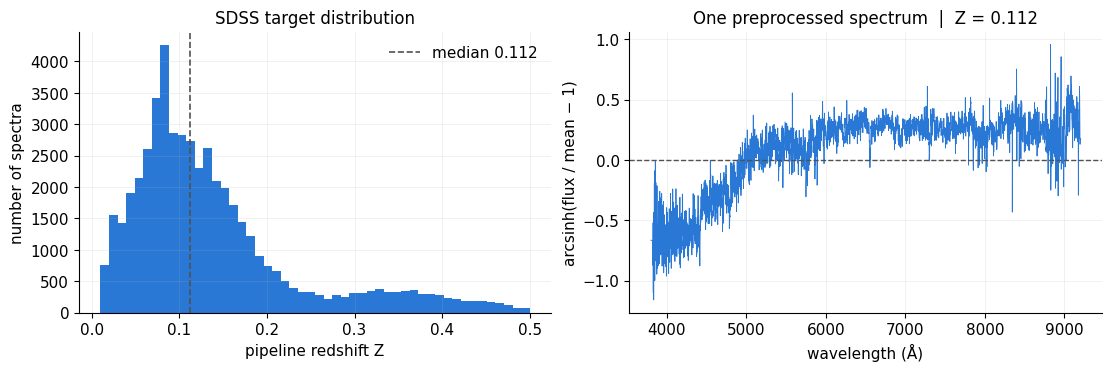

In [4]:
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11})
fig, (left, right) = plt.subplots(1, 2, figsize=(11, 3.6), constrained_layout=True)

left.hist(z, bins=50, color=BLUE)
left.axvline(np.median(z), color=INK, ls='--', lw=1.2, label=f'median {np.median(z):.3f}')
left.set(xlabel='pipeline redshift Z', ylabel='number of spectra',
         title=f'{survey.upper()} target distribution')
left.legend(frameon=False)

grid = getattr(loader, 'COMMON_GRID', None)  # SDSS resamples onto a shared grid; DESI already shares one
pixels = grid if grid is not None else np.arange(flux.shape[1])
example = int(np.argmin(np.abs(z - np.median(z))))
right.plot(pixels, flux[example], color=BLUE, lw=.6)
right.axhline(0, color=INK, ls='--', lw=1)
right.set(xlabel='wavelength (Å)' if grid is not None else 'pixel', ylabel='arcsinh(flux / mean − 1)',
          title=f'One preprocessed spectrum  |  Z = {z[example]:.3f}')

for axis in (left, right):
    axis.grid(alpha=.2, lw=.6)
    axis.spines[['top', 'right']].set_visible(False)

### Why the spectra are normalized this way

Absolute flux in a survey spectrum says more about the instrument and the object's distance than about its physics. The same galaxy observed twice, or placed twice as far away, gives a different flux scale but the same lines in the same places. Redshift lives in where those lines sit, so each spectrum is normalized against itself rather than against the population.

Three steps, each answering a specific property of the data:

- **Sigma-clipping.** Cosmic rays, dead pixels and imperfectly subtracted sky lines leave narrow spikes that are instrumental, not astronomical. Left in, they capture the scale factor and the network learns the detector. Three clipping passes drop them from the statistics before anything is measured.
- **Dividing by the mean flux.** Using the spectrum's own mean as the scale puts its continuum near 1, so `flux / mean - 1` centres the continuum on zero and leaves absorption negative and emission positive. Standardizing by mean and standard deviation instead would let one strong emission line inflate the denominator and flatten everything else.
- **arcsinh compression.** Emission lines run orders of magnitude above the continuum. A logarithm would compress them but is undefined for the negative values that absorption and sky subtraction produce; `arcsinh` is logarithmic for large values, linear near zero, and defined for both signs.

A floor on the scale factor covers faint and sky-dominated spectra, where the mean approaches zero and the division would otherwise blow up. It is expressed in survey flux units, so a release stored on a different scale needs its own value.

This is the shared AstroSpec utility, matching OmniSpectrum's `SpectrumPreprocessor`. spender normalizes differently: it divides by the median flux in a fixed *rest-frame* window (5300-5850 A), a flat stretch of continuum chosen to stay well observed out to `z ~ 0.5`. That choice is unavailable here, because locating a rest-frame window requires knowing the redshift the model is being asked to predict.

## Make train, validation, and test splits

The 70/15/15 object-level split is fixed by the seed above. Dynamic targets such as `Z` are first log-scaled, then standardized using **only the training subset**, avoiding target leakage into validation and testing. The network predicts this standardized value, then the final output is transformed back to physical units.

In [5]:
indices = rng.permutation(len(z))
train_idx, val_idx, test_idx = np.split(indices, [int(.70 * len(indices)), int(.85 * len(indices))])
targets = z[:, None]

def transform_targets(values):
    transformed = values.copy()
    for index, name in enumerate(target_names):
        if name in log_scaled_targets:
            transformed[:, index] = np.log10(transformed[:, index])
    return transformed

def invert_targets(values):
    physical = values.copy()
    for index, name in enumerate(target_names):
        if name in log_scaled_targets:
            physical[:, index] = 10 ** physical[:, index]
    return physical

transformed_targets = transform_targets(targets)
target_mean = transformed_targets[train_idx].mean(axis=0)
target_std = np.maximum(transformed_targets[train_idx].std(axis=0, ddof=1), 1e-6)

def make_loader(indices, shuffle=False):
    target = ((transformed_targets[indices] - target_mean) / target_std).squeeze(1)
    data = TensorDataset(torch.from_numpy(flux[indices]), torch.from_numpy(target))
    return DataLoader(data, batch_size=64, shuffle=shuffle)

train_loader = make_loader(train_idx, shuffle=True)
# a fixed, validation-sized slice of the training split: the per-epoch train curve then
# costs the same as the validation curve however large the training set grows
train_eval_loader = make_loader(train_idx[:len(val_idx)])
val_loader, test_loader = make_loader(val_idx), make_loader(test_idx)
len(train_idx), len(val_idx), len(test_idx)

(35000, 7500, 7500)

## Construct SpectrumEncoder with a scalar latent

`SpectrumEncoder` pools a stack of convolutions through softmax attention into an `n_latent`-dimensional vector, so setting `n_latent=1` gives one scalar target directly, no separate head needed. Consumes flux only, same as GalSpecNet.

Its default `filters`/`sizes`/`n_hidden` are the lightweight variant OmniSpectrum uses as a quick baseline, under 30K parameters. This notebook instead passes spender's own published sizes (`filters=(128, 256, 512)`, `sizes=(5, 11, 21)`, `n_hidden=(128, 64, 32)`), matching the paper (~3.1M parameters).

`dropout` applies inside both the convolutions and the MLP. At this capacity the encoder can memorize a subset this size long before it runs out of epochs, and dropout is the cheapest way to keep the training and validation curves from separating.

In [6]:
model = astrospec.create_model(
    'spectrum_encoder', n_latent=1,
    filters=(128, 256, 512), sizes=(5, 11, 21), n_hidden=(128, 64, 32), dropout=0.1,
).to(device)
print(f'{sum(parameter.numel() for parameter in model.parameters()):,} trainable parameters')

3,158,881 trainable parameters


## Train a 20-epoch draft

Twenty epochs is a deliberate first-pass budget, not a tuned stopping point. Train and validation MSE are both measured in physical Z units after each epoch, so the two curves are directly comparable and the point where validation stops improving is visible.

Two details keep that comparison meaningful. `predict` pairs each prediction with the target from the same batch rather than indexing back into `z`, which is what the shuffled training loader requires: its row order does not match `train_idx`. And the train curve is measured on `train_eval_loader`, a fixed slice of the training split the same size as the validation split, so the per-epoch cost does not grow with the training set.

In [7]:
num_epochs = 20
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
loss_fn = nn.MSELoss()
history = {'train_mse': [], 'val_mse': []}

def predict(loader):
    """Predicted and true Z in physical units, paired batch by batch.

    Reading the targets back out of the loader keeps this correct for the
    shuffled training loader, where row order does not match the split indices.
    """
    model.eval()
    predicted, actual = [], []
    with torch.no_grad():
        for x, target in loader:
            predicted.append(model(x.to(device)).cpu().squeeze(1))
            actual.append(target)

    def to_physical(values):
        return invert_targets(torch.cat(values).numpy()[:, None] * target_std + target_mean)[:, 0]

    return to_physical(predicted), to_physical(actual)

epochs = tqdm(range(num_epochs), desc='Training')
for epoch in epochs:
    model.train()
    progress = tqdm(train_loader, desc=f'Epoch {epoch + 1:02d}/{num_epochs}', leave=False)
    for x, target in progress:
        optimizer.zero_grad()
        loss = loss_fn(model(x.to(device)).squeeze(1), target.to(device))
        loss.backward(); optimizer.step()
        progress.set_postfix(train_mse=f'{loss.item():.3f}', refresh=False)
    train_prediction, train_truth = predict(train_eval_loader)
    val_prediction, val_truth = predict(val_loader)
    train_mse = np.mean((train_prediction - train_truth) ** 2)
    val_mse = np.mean((val_prediction - val_truth) ** 2)
    history['train_mse'].append(train_mse); history['val_mse'].append(val_mse)
    epochs.set_postfix(train_mse=f'{train_mse:.4f}', val_mse=f'{val_mse:.4f}')

Training: 100%|██████████| 20/20 [03:34<00:00, 10.68s/it, train_mse=0.0002, val_mse=0.0003]

Training: 100%|██████████| 20/20 [03:34<00:00, 10.72s/it, train_mse=0.0002, val_mse=0.0003]

## Evaluate on untouched spectra

The test split did not influence the model settings. Every score is computed after reversing both the standardization and the log transform, so all of them are in physical Z units.

R² and MAE describe the bulk of the sample; the MAD-score and the outlier rate describe its tails. Redshift work reports errors as Δz / (1 + z) because a fixed velocity error grows with redshift, and counts anything past ±0.15 as a catastrophic failure rather than a large error, a spectrum whose lines were matched to the wrong transition entirely. A model can look good on MAE and still fail here, which is why the figure below shows the residual distribution alongside the scalar scores.

In [8]:
prediction, truth = predict(test_loader)
residual = prediction - truth
r2 = 1 - np.sum(residual ** 2) / np.sum((truth - truth.mean()) ** 2)
mae = np.mean(np.abs(residual))
redshift_residual = residual / (1 + truth)
mad_score = 1.4826 * np.median(np.abs(redshift_residual - np.median(redshift_residual)))
outlier_fraction = np.mean(np.abs(redshift_residual) > 0.15)
print(f'{survey.upper()} test scores (unnormalized Z):')
print(f'  R²:            {r2:.4f}')
print(f'  MAE:           {mae:.4f}')
print(f'  MAD-score:     {mad_score:.6f} (Δz / (1 + z))')
print(f'  outlier rate:  {outlier_fraction:.2%} (|Δz| / (1 + z) > 0.15)')

SDSS test scores (unnormalized Z):
  R²:            0.9613
  MAE:           0.0071
  MAD-score:     0.002294 (Δz / (1 + z))
  outlier rate:  0.25% (|Δz| / (1 + z) > 0.15)


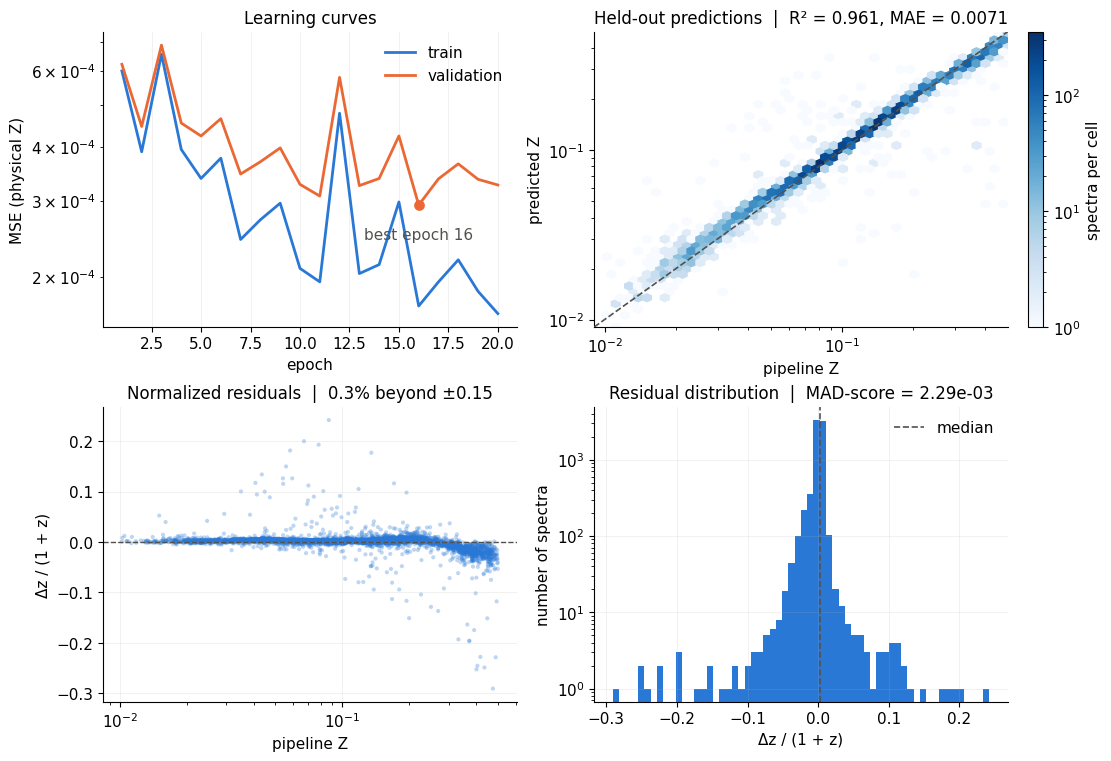

In [9]:
plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11})
fig, axes = plt.subplots(2, 2, figsize=(11, 7.5), constrained_layout=True)

axes[0, 0].plot(range(1, num_epochs + 1), history['train_mse'], color=BLUE, lw=2, label='train')
axes[0, 0].plot(range(1, num_epochs + 1), history['val_mse'], color=ORANGE, lw=2, label='validation')
best_epoch = int(np.argmin(history['val_mse']))
axes[0, 0].scatter([best_epoch + 1], [history['val_mse'][best_epoch]], color=ORANGE, s=45, zorder=3)
axes[0, 0].annotate(f'best epoch {best_epoch + 1}', (best_epoch + 1, history['val_mse'][best_epoch]),
                    textcoords='offset points', xytext=(0, -16), ha='center', va='top', color=INK)
axes[0, 0].set(xlabel='epoch', ylabel='MSE (physical Z)', yscale='log', title='Learning curves')
axes[0, 0].legend(frameon=False)
axes[0, 0].grid(alpha=.2, lw=.6)

# Z spans several decades around a median near 0.11, so both panels against Z use log axes
limits = [min(truth.min(), prediction.min()), max(truth.max(), prediction.max())]
density = axes[0, 1].hexbin(truth, prediction, gridsize=45, mincnt=1, bins='log', cmap='Blues',
                            xscale='log', yscale='log')
axes[0, 1].plot(limits, limits, color=INK, ls='--', lw=1.2, zorder=3)
axes[0, 1].set(xlabel='pipeline Z', ylabel='predicted Z', xlim=limits, ylim=limits,
               title=f'Held-out predictions  |  R\u00b2 = {r2:.3f}, MAE = {mae:.4f}')
fig.colorbar(density, ax=axes[0, 1], label='spectra per cell')

axes[1, 0].axhline(0, color=INK, ls='--', lw=1)
axes[1, 0].scatter(truth, redshift_residual, s=9, alpha=.3, color=BLUE, edgecolors='none')
axes[1, 0].set(xlabel='pipeline Z', ylabel='\u0394z / (1 + z)', xscale='log',
               title=f'Normalized residuals  |  {outlier_fraction:.1%} beyond \u00b10.15')
axes[1, 0].grid(alpha=.2, lw=.6)

axes[1, 1].hist(redshift_residual, bins=60, color=BLUE)
axes[1, 1].axvline(np.median(redshift_residual), color=INK, ls='--', lw=1.2, label='median')
axes[1, 1].set(xlabel='\u0394z / (1 + z)', ylabel='number of spectra', yscale='log',
               title=f'Residual distribution  |  MAD-score = {mad_score:.2e}')
axes[1, 1].legend(frameon=False)
axes[1, 1].grid(alpha=.2, lw=.6)

for axis in axes.flat:
    axis.spines[['top', 'right']].set_visible(False)

## Next steps

Switch to DESI and compare the target distribution and held-out plot, not just MAE. The selection here is deliberately simple: one class, the pipeline's own quality flag, and spender's redshift bound. A serious result would go further: control the target distribution rather than inheriting the survey's, use the per-object `Z_ERR` the release ships, and report uncertainty-aware metrics instead of point estimates. Those survey-specific decisions belong above the model API rather than inside AstroSpec itself.